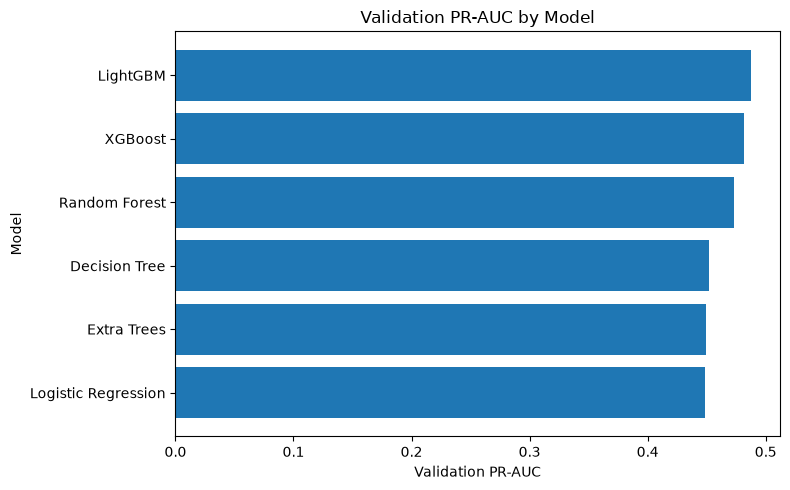

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"

comparison = pd.read_csv(PROCESSED / "step4_initial_validation_model_comparison.csv")
plot_data = comparison.sort_values("pr_auc", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_data["model"], plot_data["pr_auc"])
plt.title("Validation PR-AUC by Model")
plt.xlabel("Validation PR-AUC")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(REPORTS / "step6_validation_pr_auc_model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

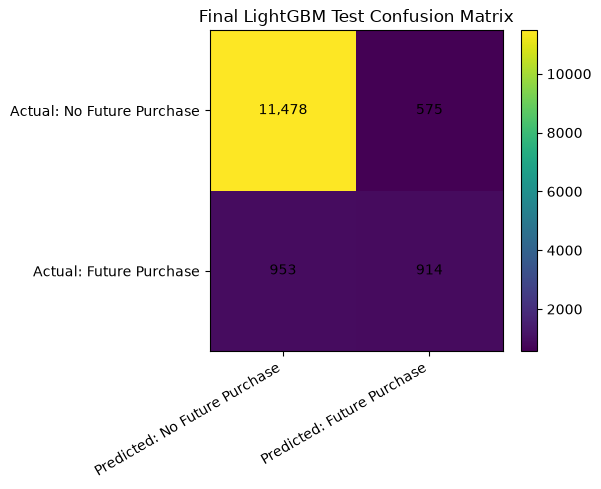

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

cm = pd.DataFrame(
    [[11478, 575], [953, 914]],
    index=["Actual: No Future Purchase", "Actual: Future Purchase"],
    columns=["Predicted: No Future Purchase", "Predicted: Future Purchase"]
)

plt.figure(figsize=(6, 5))
plt.imshow(cm, aspect="auto")
plt.title("Final LightGBM Test Confusion Matrix")
plt.xticks(range(len(cm.columns)), cm.columns, rotation=30, ha="right")
plt.yticks(range(len(cm.index)), cm.index)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm.iloc[i, j]:,}", ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(REPORTS / "step6_final_test_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

![](../data/img/slide1.png)

## **OBJECTIVE:**
### `Predict whether an eCommerce customer session will result in a future purchase after observing only the first two session events.`
## **FINAL MODEL:** 
### `LightGBM`  
## **PREDICATION TARGET:** 
### `future_purchase`

# Problem Formulation

## Business Question
Can early customer-session behavior predict whether a user will purchase later in the same session?

## ML Framing
| Component | Definition |
|---|---|
| Task | Binary classification |
| Target | `future_purchase` |
| Positive class | Purchase after first two events |
| Prediction point | After event 2 |
| Main metric | PR-AUC / Average Precision |

## Why PR-AUC?
Future purchase is a minority outcome, so accuracy alone is not enough.

# Data Funnel

## Dataset Construction

| Stage | Count |
|---|---:|
| Raw event records scanned | 66,589,268 |
| Session-preserved sampled events | 982,585 |
| Unique sampled sessions | 173,519 |
| Leakage-safe modeling sessions | 92,799 |
| Final future-purchase rate | 12.58% |

## Key Design Choice
A session-preserved sample was used so each selected session kept its full event sequence.

# Leakage-Safe Target Design

## Observation Window
Only the first two events were used as predictors.

## Target Window
The model predicts whether a purchase occurs after the second event.

| Rule | Purpose |
|---|---|
| Use first two events only | Prevent target leakage |
| Exclude purchases inside observation window | Avoid predicting already-known purchases |
| Chronological train/validation/test split | Simulate future prediction |

## Timeline

**Event 1 + Event 2 → Prediction → Later Events → Future Purchase Target**

# Cleaning and Preprocessing

## Cleaning Decisions

| Issue | Treatment | Justification |
|---|---|---|
| Exact duplicate rows | Removed 1,921 rows | Avoid inflated behavior counts |
| Missing brand/category | Standardized as `unknown` | Missing values may carry signal |
| Zero-price events | Retained | Valid customer interactions |
| Price aggregation | Positive prices only | Prevent zero prices distorting price features |
| High-price outliers | Retained | May represent valid catalog items |

## Validation
Deduplication did not change any session-level conversion labels.

# EDA: Early Behavior Signals

## Key Findings
- Complete-session conversion rate: **6.76%**
- Leakage-safe future-purchase rate: **12.58%**
- Early cart activity had the strongest behavioral relationship with future purchase
- Faster early-session movement was associated with higher future-purchase likelihood

## Technical Implication
Early behavior is predictive enough to support a two-event observation window.

# Feature Engineering

## Feature Families

| Feature Family | Examples |
|---|---|
| Early behavior | `early_cart_count`, `early_unique_products` |
| Product diversity | `early_unique_categories`, `early_unique_brands` |
| Product context | first/second category and brand |
| Price | first/second positive observed prices |
| Timing | `early_event_gap_log1p`, first event hour |
| Calendar | day of week, weekend flag |

## Leakage Control
No features were derived from events after the second event.

# PCA and Feature Selection

## PCA
- Fitted on training data only
- Preprocessed feature count: **511**
- PC1 + PC2 explained variance: **29.79%**
- 26 components needed for 80% variance
- PCA used for exploration, not final modeling

## Embedded Feature Selection
- L1 Logistic Regression used on training data only
- Raw candidate features: **17**
- Retained features: **16**
- Excluded feature: `event_type_first`

## Conclusion
Original engineered features were more interpretable.

# Model Comparison

## Models Evaluated
- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- XGBoost
- LightGBM

## Validation PR-AUC

![](../reports/step6_validation_pr_auc_model_comparison.png)

## Selection
LightGBM achieved the strongest validation PR-AUC.

# Final Model Evaluation

## Final Model
**LightGBM**, threshold = **0.65**

| Metric | Test Result |
|---|---:|
| PR-AUC | 0.4824 |
| ROC-AUC | 0.7802 |
| Accuracy | 0.8902 |
| Precision | 61.38% |
| Recall | 48.96% |
| F1-score | 0.5447 |
| Sessions targeted | 1,489 |
| Targeting rate | 10.70% |

## Interpretation
The model identifies a smaller high-propensity group with strong precision.

# Final Test Confusion Matrix

![](../reports/step6_final_test_confusion_matrix.png)

## Interpretation
- True positives: **914**
- False positives: **575**
- False negatives: **953**
- True negatives: **11,478**

## Technical Trade-off
The threshold prioritizes precision and targeted-session efficiency, but still misses some future purchasers.

# Feature Importance

## Final LightGBM Feature Importance

![](../reports/step4_final_lightgbm_feature_importance.png)

## Top Predictors
1. `early_event_gap_log1p`
2. `price_for_aggregation_second`
3. `price_for_aggregation_first`
4. `brand_clean_second`
5. `category_code_clean_second`

## Interpretation
The model relies on early session speed, price exposure, brand, category, and timing context.

# PDP / ICE Explainability

## Early Cart Count

![](../reports/step5_pdp_ice_early_cart_count.png)

## Interpretation
The model sharply increases predicted future-purchase probability when a cart event appears within the first two events.

This confirms the EDA and segment-audit finding that early cart activity is a strong purchase-intent signal.

# PDP / ICE: Event Gap and Price

## Event Gap

![](../reports/step5_pdp_ice_early_event_gap_log1p.png)

## Second Observed Price

![](../reports/step5_pdp_ice_price_for_aggregation_second.png)

## Interpretation
- Longer gaps between the first two events generally reduce predicted purchase probability.
- Higher second observed price tends to lower predicted probability in the model.
- PDP/ICE explains model behavior, not causality.

# Ethical AI and Bias Audit

## Sensitive Attribute Review
The dataset does not contain:
- gender
- race
- age
- income
- socioeconomic status

## Fairness Limitation
Formal demographic fairness metrics could not be calculated.

## Segment-Level Audit
Instead, the model was audited across:
- product category
- brand
- price band
- first-event timing
- early cart behavior
- early event-gap behavior

## Key Risk
The model favors immediate-intent sessions and may under-target slower exploratory shoppers.

# Technical Limitations

## Main Limitations
- Dataset covers only April 2020
- No direct demographic fairness audit possible
- Class imbalance remains important
- False negatives are still significant
- Model behavior may drift over time
- Feature importance and PDP/ICE are not causal explanations

## Responsible Use
The model should be used for prioritization, not exclusion.

# Conclusion and Future Work

## Final Conclusion
A leakage-safe LightGBM model was developed to predict future purchase intent after only two session events.

## Technical Outcome
- Best validation model: **LightGBM**
- Final test PR-AUC: **0.4824**
- Final test precision: **61.38%**
- Targeted only **10.70%** of test sessions

## Future Work
- Validate on newer months of data
- Add customer-level history if available
- Monitor performance by segment
- Recalibrate thresholds by campaign objective
- Retrain periodically to handle drift